# 1. Introduction

In the contemporary landscape of urban transportation, car accidents remain a significant concern with far-reaching implications for public safety and road infrastructure. Analyzing the factors contributing to accidents and understanding their severity is crucial for devising effective preventive measures and enhancing road safety standards. In this project, we are going to explore a dataset of over 7M car accidents for some insights, and then build a model to predict severity based on available information.

In [1]:
from matplotlib import ticker

# We will work with a lot of large numbers
# Which is why I created this function and hid it here

def large_numbers_formatter(decimals=1):
    """Returns a FuncFormatter that formats large numbers in K, M, B notation."""
    def formatter(x, pos):
        if abs(x) >= 1_000_000_000:
            return f"{x / 1_000_000_000:.{decimals}f}B"
        elif abs(x) >= 1_000_000:
            return f"{x / 1_000_000:.{decimals}f}M"
        elif abs(x) >= 1_000:
            return f"{x / 1_000:.{decimals}f}K"
        return f"{x:.{decimals}f}"
    
    return ticker.FuncFormatter(formatter)

In [2]:
# Importing libraries for data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset (use data/ when running locally; see README)
import os
_path = "data/US_Accidents_March23.csv"
if not os.path.exists(_path):
    _path = "/kaggle/input/us-accidents/US_Accidents_March23.csv"
accidents = pd.read_csv(_path, parse_dates=['Start_Time', 'End_Time'])

accidents.head()

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


# 2. Data Exploration and Preprocessing:

Before going to the main part of our analysis, let's check the main features of the dataset and also ensure data quality. The dataset has a big range of attributes: severity, weather conditions, road features, and temporal characteristics. For now, we will focus on missing values, outliers, and inconsistencies.

In [3]:
# Display main data characteristics
round(accidents.describe())

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7728394.0,7728394.0,7728394.0,4325632.0,4325632.0,7728394.0,7564541.0,5729375.0,7554250.0,7587715.0,7551296.0,7157161.0,5524808.0
mean,2.0,36.0,-95.0,36.0,-96.0,1.0,62.0,58.0,65.0,30.0,9.0,8.0,0.0
std,0.0,5.0,17.0,5.0,18.0,2.0,19.0,22.0,23.0,1.0,3.0,5.0,0.0
min,1.0,25.0,-125.0,25.0,-125.0,0.0,-89.0,-89.0,1.0,0.0,0.0,0.0,0.0
25%,2.0,33.0,-117.0,33.0,-118.0,0.0,49.0,43.0,48.0,29.0,10.0,5.0,0.0
50%,2.0,36.0,-88.0,36.0,-88.0,0.0,64.0,62.0,67.0,30.0,10.0,7.0,0.0
75%,2.0,40.0,-80.0,40.0,-80.0,0.0,76.0,75.0,84.0,30.0,10.0,10.0,0.0
max,4.0,49.0,-67.0,49.0,-67.0,442.0,207.0,207.0,100.0,59.0,140.0,1087.0,36.0


* From this information we can see that there are some missing values in a few columns. We'll deal with them while preprocssing the data for the ML model;
* We can use some of the columns to derive new useful information about the car crashes;
* It's good to see that there are no negative values where they shouldn't exist (for example, negative precipitation), which means we don't have to hunt for very weird data.

In [4]:
# First, let's check the amount of missing variables:
share_missing = round(accidents.isna().mean().sort_values(ascending=False), 4) * 100
display(share_missing[share_missing != 0])

End_Lat                  44.03
End_Lng                  44.03
Precipitation(in)        28.51
Wind_Chill(F)            25.87
Wind_Speed(mph)           7.39
Visibility(mi)            2.29
Wind_Direction            2.27
Humidity(%)               2.25
Weather_Condition         2.24
Temperature(F)            2.12
Pressure(in)              1.82
Weather_Timestamp         1.56
Nautical_Twilight         0.30
Civil_Twilight            0.30
Sunrise_Sunset            0.30
Astronomical_Twilight     0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02
dtype: float64

For most columns it seems we just don't have info in a negligible amount of cases, but: 
* The end place could be missing because the distance is just not that significant
* precipitation and wind chill could be missing because the values are zero.

Let's check the values in these cases below and fill them or adapt accordingly.

## Missing ending positions

In [5]:
# Checking if all missing latitudes have a corresponding missing longitude
display(accidents[accidents['End_Lat'].isna()]['End_Lng'].value_counts())

Series([], Name: End_Lng, dtype: int64)

Seems like there's no case where the lat is missing, but the longitude is not (and vice versa), this is good, as having something like that would imply trickier errors in the data.

In [6]:
# Checking the median distance for rows where end latitude is missing
accidents['Missing End_Lat'] = accidents['End_Lat'].isna()
display(accidents.groupby('Missing End_Lat')['Distance(mi)'].median())

Missing End_Lat
False    0.283
True     0.000
Name: Distance(mi), dtype: float64

We have established that for cases where there is no ending position, the median distance is zero, so indeed the missing values seem related to small distances. Nevertheless, there are a few outliers: the maximum distance for missing positions is 441 miles. this seems unreal.

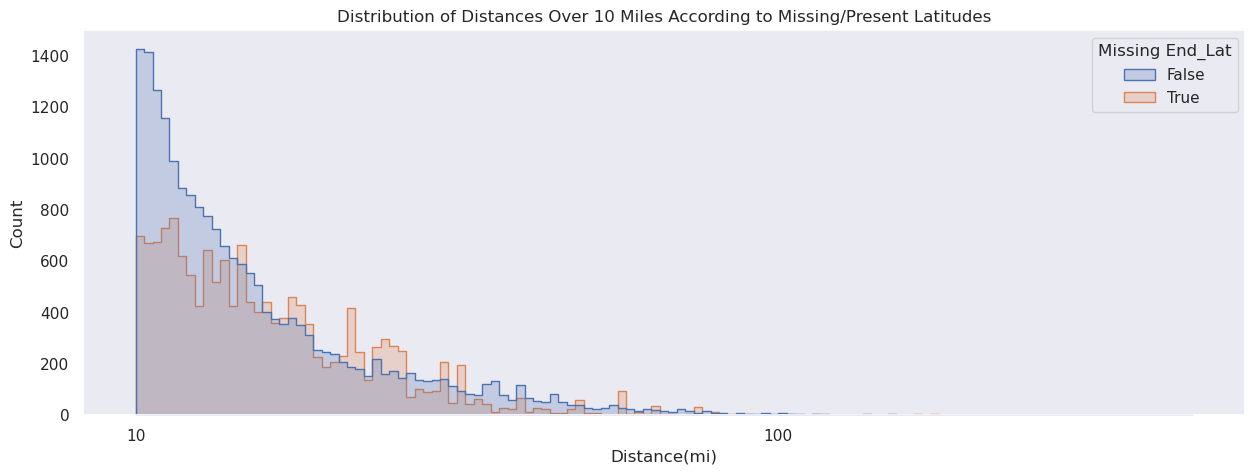

In [7]:
# Setting style for my charts

sns.set(style="dark", 
        palette="deep", 
        context="notebook",)

plt.figure(figsize=(15,5))

sns.histplot(x='Distance(mi)', 
             data=accidents[accidents['Distance(mi)'] >= 10], 
             hue='Missing End_Lat', 
             log_scale=(True, False),
             element='step')
plt.gca().xaxis.set_major_formatter(large_numbers_formatter(0))

plt.title('Distribution of Distances Over 10 Miles According to Missing/Present Latitudes')
plt.show()

There are a few thousands of accidents with missing end coordinates and over 10 miles distance. While the number might be big, the dataset has over 7 million rows, and these cases seem quite extreme outliers. Let's see if their description shows any clues of what is happening.

In [8]:
accidents[accidents['Distance(mi)'] >= 10].sort_values('Distance(mi)', ascending=False)['Description'][:10].to_list()

['Lane blocked due to accident on US-93 both ways from US-50 Great Basin Blvd to I-80 Exits 352 352A.',
 'Right lane closed due to crash on I-10 Westbound from Exits 239A 239B Louisa St to Exit 29 Lake Shore Dr.',
 'Accident on I-95 Southbound from Exit 77 Hodges Chapel Rd to Exit 68 SC-61 Augusta Hwy.',
 'Two lanes blocked due to accident on I-25 both ways between Exit 293 County Hwy-126 5 and Exit 213 I-70.',
 'Single alternate line traffic due to accident on US-93 Great Basin Hwy both ways from 6th St to US-93-ALT.',
 'Queueing traffic and left lane closed due to accident on I-70 Eastbound between Exit 52 MO-T and Exit 203 MO-W.',
 'Accident on US-101 El Camino Real Northbound between Exits 47B 47C Wendy Dr and Exit 189 4th St.',
 'Left lane blocked due to accident on US-30 both ways from T Ave to Exit 142 X Ave.',
 'Left lane blocked due to accident on I-76 Eastbound between Irwin and Pittsburgh.',
 'Main roadway closed due to crash on US-285 both ways from Mccue Rd to Gonzales Loo

*Well*, I am not an expert in US highways, but normally accidents that involve blocking two lanes or both ways are usually very severe and can cause kilometer-long traffic jams in busy highways. Could it get over 100 miles distance? I don't know, as I speak kilometers, but also from the field description it's not possible to say whether the distance is the total distance affected by the accident (including traffic jams), or if the distance should be only the distance from the beginning to the end of the accident area. Anyway, I am still not sure if I should leave car accidents with over 10 miles distance in the dataset, but let's try to feature engineer these two conditions from the description.

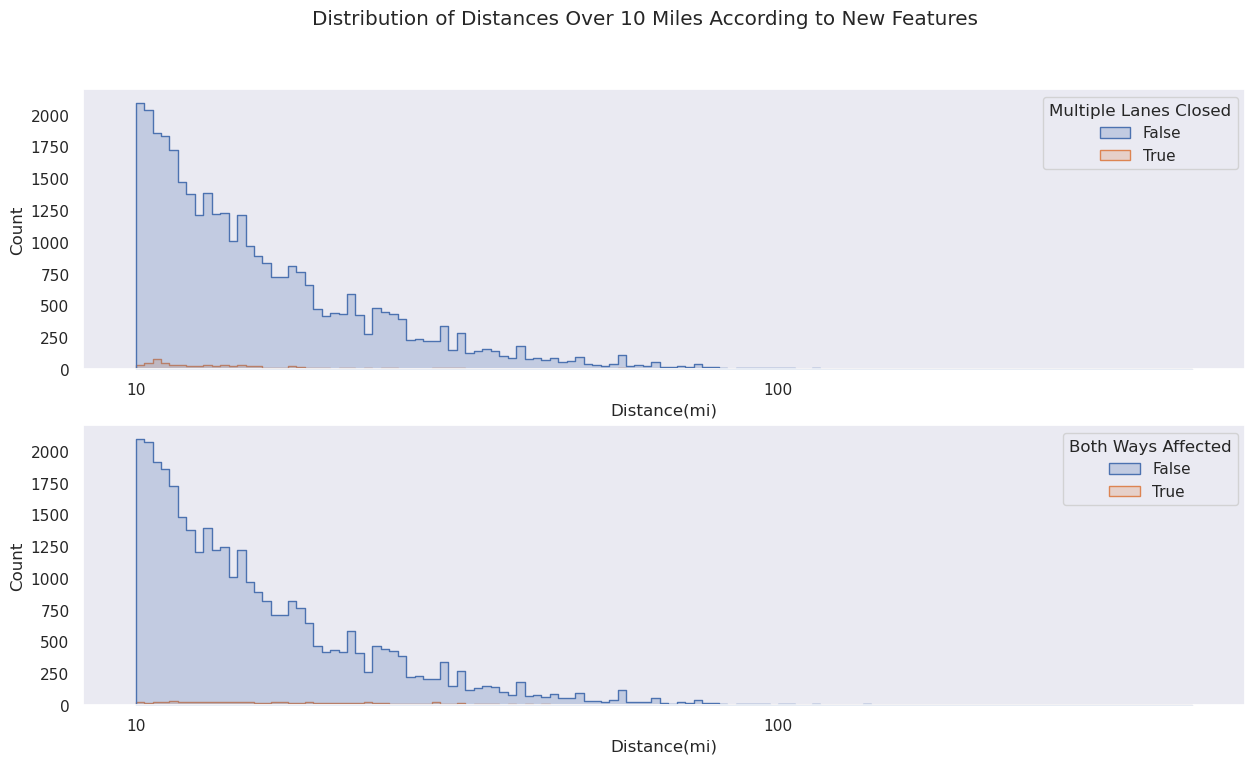

In [9]:
accidents['Multiple Lanes Closed'] = accidents['Description'].str.contains('lanes.*blocked|lanes.*closed|lanes.*obstructed').astype('boolean')
accidents['Both Ways Affected'] = accidents['Description'].str.contains('both.*ways').astype('boolean')

fig, (ax1, ax2) = plt.subplots(2,1,figsize=(15,8))

for ax, hue in zip([ax1,ax2],['Multiple Lanes Closed', 'Both Ways Affected']):
    sns.histplot(x='Distance(mi)',
                 data=accidents[accidents['Distance(mi)'] >= 10],
                 hue=hue,
                 log_scale=(True, False),
                 element='step',
                ax=ax)
    ax.get_xaxis().set_major_formatter(large_numbers_formatter(0))

plt.suptitle('Distribution of Distances Over 10 Miles According to New Features')
plt.show()

I was expecting these feature to become more frequent as distances increase, but apparently not. Anyway, they might be useful in the second part of this notebook, where I'll try to predict severity.

## Column Types

In [10]:
# Checking data types
accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 49 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     object        
 1   Source                 object        
 2   Severity               int64         
 3   Start_Time             datetime64[ns]
 4   End_Time               datetime64[ns]
 5   Start_Lat              float64       
 6   Start_Lng              float64       
 7   End_Lat                float64       
 8   End_Lng                float64       
 9   Distance(mi)           float64       
 10  Description            object        
 11  Street                 object        
 12  City                   object        
 13  County                 object        
 14  State                  object        
 15  Zipcode                object        
 16  Country                object        
 17  Timezone               object        
 18  Airport_Code          

Nothing in this long list of columns draws my attention right now, so let's move on to the EDA part of the project.

# 3. Exploratory Data Analysis (EDA):

Now we understand better the missing values and the data types of the dataset, we can move on to the EDA part and create a few visualizations:

* Temporal Patterns and Severity Analysis

We will make a detailed breakdown of accident events by hour. But our focus goes beyond mere representation. Our visualizations will show how severe the accidents are and how often they happen. This picture will help us see how things change during the 24-h period and how they affect accident frequency and severity.

* Correlation of Severity with Roadway Attributes

A crucial aspect of our analysis lies in the examination of how diverse road features influence accident severity. I will use a correlation chart that show how accidents are related to different road characteristics. These insights might offer a deeper understanding of the variables that may exacerbate or mitigate accident severity.

* Spatial Insight through Heatmapping

I'll make a spatial analysis is in the form of a geographically oriented heatmap, which shows where accidents are more likely to happen. This visualization leverages a gradient spectrum to portray the density of accidents, enabling us to pinpoint specific regions that demand closer attention. 

## Temporal Breakdown

In [11]:
from matplotlib.ticker import PercentFormatter

# Changing Severity to Category for Visualizations
accidents['Severity'] = pd.Categorical(accidents['Severity'], categories=[1,2,3,4], ordered=True)

# Extracting hour of day from 'Start_Time'
accidents['Start Hour'] = accidents['Start_Time'].dt.hour

# Charts for visualizing Frequencies per hour
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,7))

hour_counts = accidents.pivot_table(index='Start Hour', columns='Severity', values='ID', aggfunc='count')
hour_counts.plot(kind='line', marker='o', ax=ax1)

ax1.get_yaxis().set_major_formatter(large_numbers_formatter(0))
ax1.set_title('Accident Frequency by Hour')

hour_incidence = hour_counts.div(hour_counts.sum(axis=1), axis=0)
hour_incidence.plot(kind='line', marker='o', ax=ax2)

ax2.set_title('Acccident Severity Ratio by Hour')
ax2.get_yaxis().set_major_formatter(PercentFormatter(xmax=1.0))
                                  
plt.suptitle('Accident Frequency & Severity Ratio by Hour')
plt.show()

* Accidents are clearly affected by the time of day: As expected, most accidents occur during the commute from home to work or from work to home;
* But when we check the Severity Ratio, there's also a clear increase in the frequency of highest-severity accidents from 23h to 4h;

Since we started talking about time, let's get a few more insights from this data by extracting days of the week and holidays.

In [12]:
import holidays # Testing the holidays library for the first time!

# Creating a mapping for the days of the week
day_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Getting temporal data from the start time column
accidents['Day of Week'] = accidents['Start_Time'].dt.day_of_week
accidents['Day of Week'] = accidents['Day of Week'].map(day_mapping)
accidents['Day of Week'] = pd.Categorical(accidents['Day of Week'], categories=day_mapping.values(), ordered=True)

# Getting US holidays
us_holidays = holidays.US(years=range(accidents['Start_Time'].dt.year.min(), accidents['Start_Time'].dt.year.max()+1))

# Creating a Boolean column
accidents['Holiday'] = accidents['Start_Time'].dt.date.astype('datetime64').isin(us_holidays)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(15,7))

# Using pivots for faster plotting (7M rows folks)
dow_pivot = accidents.pivot_table(index='Day of Week', columns='Severity', values='ID', aggfunc='count')
dow_pivot = dow_pivot.div(dow_pivot.sum(axis=0), axis=1)
dow_pivot.plot(ax=ax1, marker='o')

ax1.set_title('Acccident Distribution Across Days of the Week')
ax1.get_yaxis().set_major_formatter(PercentFormatter(xmax=1.0))

holidays_pivot = accidents.pivot_table(index='Severity', columns='Holiday', values='ID', aggfunc='count')
holidays_pivot = holidays_pivot.div(holidays_pivot.sum(axis=0), axis=1)
holidays_pivot.plot(ax=ax2, kind='bar')

ax2.set_title('Share of Accident Severity on Holidays vs Normal Days')
ax2.get_yaxis().set_major_formatter(PercentFormatter(xmax=1.0))
ax2.tick_params('x', rotation=0)
plt.show()

* Low-severity accidents are much more likely to occur during weekdays than weekends, whereas that distribution is more balanced for high-severity accidents;
* Holidays also seem to have a higher share of accidents with severity 2 and 4 than normal days;

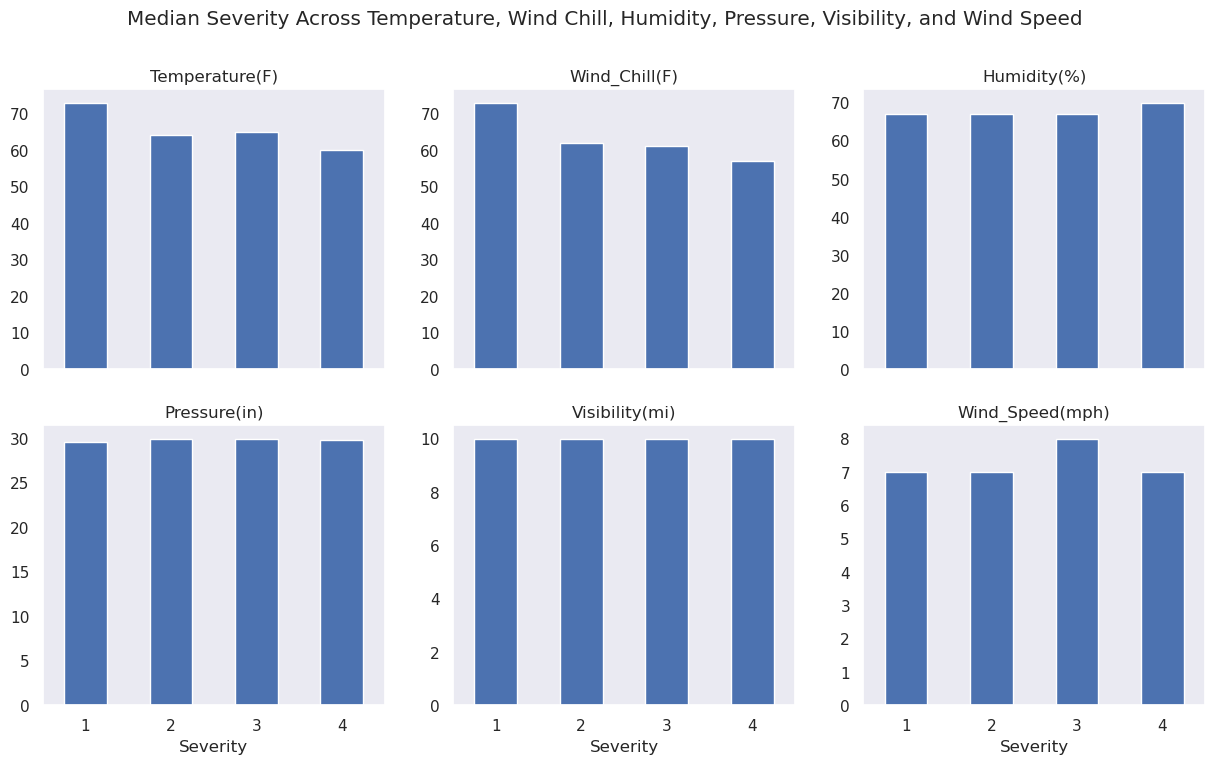

In [13]:
fig, ((ax1,ax2,ax3),(ax4,ax5,ax6)) = plt.subplots(2,3,figsize=(15,8), sharex=True)

# Chosen metrics for the chart below
metrics_list = ['Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

# Creating a super chart with multiple numerical features
for ax, metric in zip([ax1,ax2,ax3,ax4,ax5,ax6], metrics_list):
    metric_pivot = accidents.pivot_table(index='Severity', values=metric, aggfunc='median')
    metric_pivot.plot(kind='bar', ax=ax, legend=False)
    ax.set_title(metric)
    ax.tick_params('x',rotation=0)

plt.suptitle('Median Severity Across Temperature, Wind Chill, Humidity, Pressure, Visibility, and Wind Speed')
plt.show()

* Lower median temperature and wind chill clearly contribute to higher-severity accidents, likely;
* Higher humidity is also associated with higher severity;
* The relation between wind speed and severity is less straightforward, with higher wind speed being associated with severity 3, but not with severity 4;
* Other metrics have some small effects on severity.

## Calculating Accident-Prone Places
We already checked features of the dataset related to time and dates, then moved on to see how our numerical features vary with severity. Now let's check our boolean columns, which are mostly references to specific places of roads.

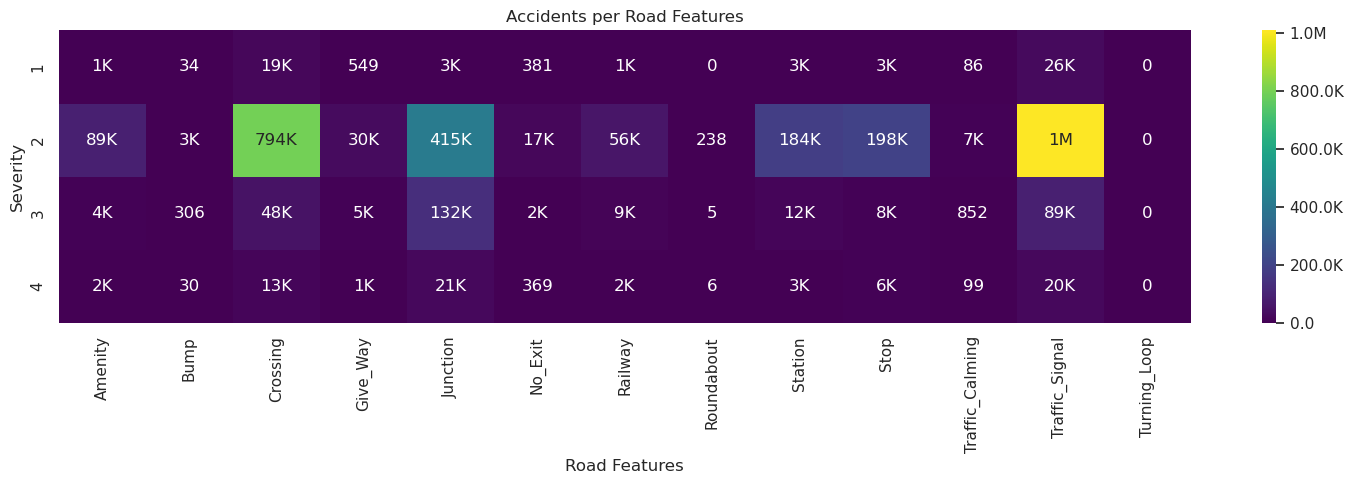

In [14]:
# Selecting boolean columns for heatmap
booleans = accidents.select_dtypes('boolean').columns.to_list()[:-4]

# Calculating the number of accidents for each combination of severity and boolean columns
severity_bools = accidents.groupby('Severity')[booleans].sum()

# Creating a heatmap to visualize the relationship between accident severity and boolean columns
plt.figure(figsize=(15, 5))

# Formatting numbers for heatmap
formatter = large_numbers_formatter(0)
formatted_annot = severity_bools.applymap(lambda x: formatter(x, None))

# heatmapping
heatmap = sns.heatmap(severity_bools, annot=formatted_annot, cmap='viridis', fmt='')

# Getting the colorbar from the heatmap object
cbar = heatmap.collections[0].colorbar

# Applying formatter to the colorbar
cbar.ax.yaxis.set_major_formatter(large_numbers_formatter(1))

plt.title('Accidents per Road Features')
plt.xlabel('Road Features')
plt.ylabel('Severity')
plt.tight_layout()

plt.show()

From our heatmap, we can see that:

* Junctions, crossings and traffic signals tend to have most car accidents;
* Junctions and traffic signals tend to have the most severe accidents;
* Roundabouts and Turning Loops have the least accidents, although Turning Loops are suspiciously low and we might want to check this column later;

## Visualizing States According to Ratio of Severe Accidents

Let's also have a look on the accident data

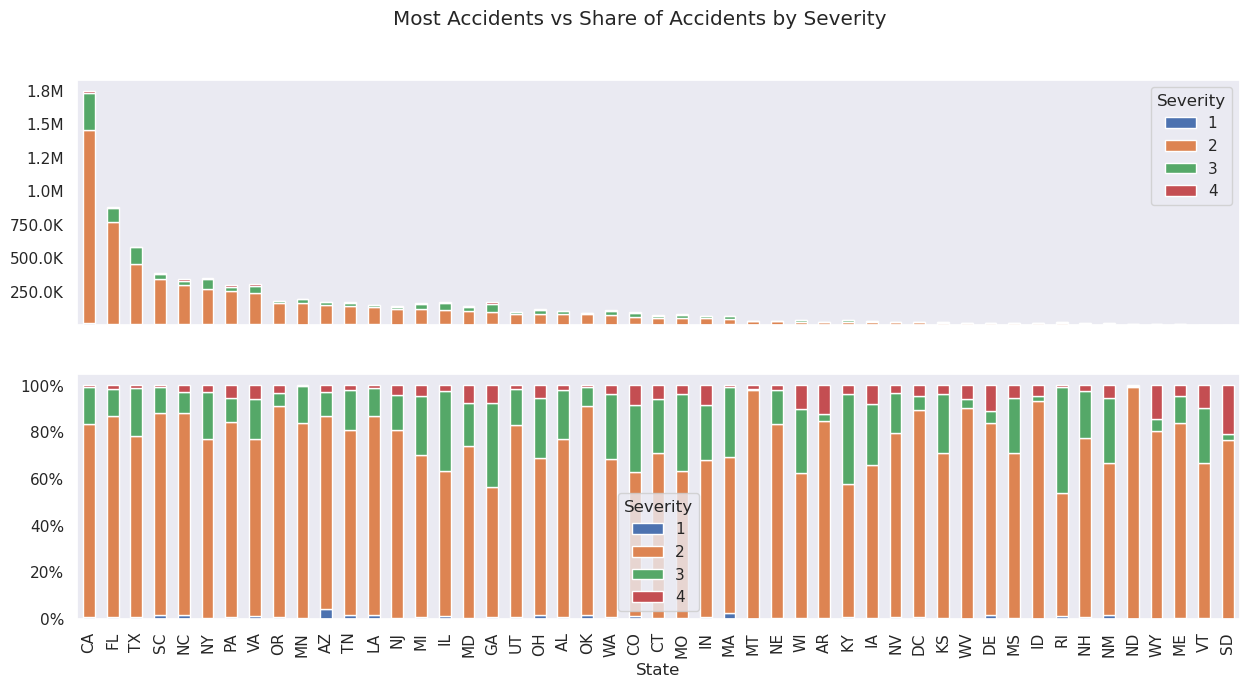

In [15]:
# Calculating data by state
most_accidents = accidents.pivot_table(index='State', columns='Severity', values='ID',  aggfunc='count').sort_values(2, ascending=False)
accident_ratio = most_accidents.div(most_accidents.sum(axis=1), axis=0).dropna(how='all')

# Creating plots
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(15,7),sharex=True)

# Absolute number of accidents
most_accidents.plot(kind='bar', stacked=True, ax=ax1)
ax1.get_yaxis().set_major_formatter(large_numbers_formatter(1))

# Share of severe accidents
accident_ratio.plot(kind='bar', stacked=True, ax=ax2)
ax2.get_yaxis().set_major_formatter(PercentFormatter(1))

plt.suptitle('Most Accidents vs Share of Accidents by Severity')
plt.show()

* California, Florida and Texas are the states with the most accidents. These are all states with a large population, and are bound to have more accidents;
* South Dakota, Wyoming and Arkansas are the states with the highest share of severe accidents. South Dakota has the least accidents in our chart, so even a high share of severe accidents is probably a very small number;

## Folium Map Visualization

* I should note that this heatmap is not scaled to account for traffic levels in these areas, which means it does not show the rate of accidents relative to traffic, but simply the absolute number of accidents.
* Also worth noting that the data is limited to a few states, as seen in the map below.

Make this Notebook Trusted to load map: File -> Trust Notebook <iframe srcdoc="<!DOCTYPE html>
<html>
<head>
 
 <meta http-equiv="content-type" content="text/html; charset=UTF-8" />
 
 <script>
 L_NO_TOUCH = false;
 L_DISABLE_3D = false;
 </script>
 
 <style>html, body {width: 100%;height: 100%;margin: 0;padding: 0;}</style>
 <style>#map {position:absolute;top:0;bottom:0;right:0;left:0;}</style>
 <script src="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js"></script>
 <script src="https://code.jquery.com/jquery-1.12.4.min.js"></script>
 <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js"></script>
 <script src="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.js"></script>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://netdna.bootstrapcdn.com/bootstrap/3.0.0/css/bootstrap.min.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@fortawesome/fontawesome-free@6.2.0/css/all.min.css"/>
 <link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/Leaflet.awesome-markers/2.0.2/leaflet.awesome-markers.css"/>
 <link rel="stylesheet" href="https://cdn.jsdelivr.net/gh/python-visualization/folium/folium/templates/leaflet.awesome.rotate.min.css"/>
 
 <meta name="viewport" content="width=device-width,
 initial-scale=1.0, maximum-scale=1.0, user-scalable=no" />
 <style>
 #map_faa341155c8718906e87ee53af78e6e6 {
 position: relative;
 width: 100.0%;
 height: 100.0%;
 left: 0.0%;
 top: 0.0%;
 }
 .leaflet-container { font-size: 1rem; }
 </style>
 
 <script src="https://cdn.jsdelivr.net/gh/python-visualization/folium@main/folium/templates/leaflet_heat.min.js"></script>
</head>
<body>
 
 
 <div class="folium-map" id="map_faa341155c8718906e87ee53af78e6e6" ></div>
 
</body>
<script>
 
 
 var map_faa341155c8718906e87ee53af78e6e6 = L.map(
 "map_faa341155c8718906e87ee53af78e6e6",
 {
 center: [36.20119454946413, -94.70254538793334],
 crs: L.CRS.EPSG3857,
 zoom: 4.4,
 zoomControl: true,
 preferCanvas: false,
 }
 );

 

 
 
 var tile_layer_122d6e8de5ad68da8c5998e7664b79ec = L.tileLayer(
 "https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png",
 {"attribution": "Data by \u0026copy; \u003ca target=\"_blank\" href=\"http://openstreetmap.org\"\u003eOpenStreetMap\u003c/a\u003e, under \u003ca target=\"_blank\" href=\"http://www.openstreetmap.org/copyright\"\u003eODbL\u003c/a\u003e.", "detectRetina": false, "maxNativeZoom": 18, "maxZoom": 18, "minZoom": 0, "noWrap": false, "opacity": 1, "subdomains": "abc", "tms": false}
 ).addTo(map_faa341155c8718906e87ee53af78e6e6);
 
 
 var heat_map_e2dc7e9df0f86f32d1e0eb1f2a249ba4 = L.heatLayer(
(output truncated for portability)